<a href="https://colab.research.google.com/github/suyash01-ggv/xray_image_classification/blob/main/xray_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow

In [2]:
!ls drive/MyDrive/Deep learning

ls: cannot access 'drive/MyDrive/Deep': No such file or directory
ls: cannot access 'learning': No such file or directory


In [3]:
!ls drive/MyDrive

 1000140785.png
 1744021540894.jpg
'apaar id suyash.pdf'
 Btech_Students_CBDE.docx
'Chemistry allen'
 Classroom
'Colab Notebooks'
'collab extra files '
'Copy of 33a87cb2-259b-498f-abc9-53e04483631d-1_all_345.jpg'
'Deep learning'
'Final - Prototype - Proposal Submission Format CBDE_Rev1.docx (2).pdf (1).pdf'
'Getting started.pdf'
 IMG-20220915-WA0021.jpg
'IMG_20251219_094021_481 (1).jpg'
'IMG_20251219_094021_481 (2).jpg'
 IMG_20251219_094021_481.jpg
 InShot_20260925_085606267.mp4
'Onboarding notes.gdoc'
 Physics
'Physics allen'
'resume.25 (1).pdf'
 resume.25.pdf
 Screenshot_20220915-143831.png
'Screenshot_20220922-155811 (1).png'
 Screenshot_20220922-155811.png
 Screenshot_20250716-172320.jpg
 Screenshot_20251111-133318.jpg
'shramsathi proposal final.pdf'
'Singapore India Hackathon 2026- suyash.pdf'
 Suyash
'suyashgupta IT 2024.pdf'
 Suyash_Gupta_Resume.pdf
'Untitled document (1).gdoc'
'Untitled document (2).gdoc'
'Untitled document.gdoc'
'Untitled folder'
'Untitled folder (1)'
'Untitle

In [4]:
!unzip drive/MyDrive/chest_xray-20250726T110654Z-1-001.zip

unzip:  cannot find or open drive/MyDrive/chest_xray-20250726T110654Z-1-001.zip, drive/MyDrive/chest_xray-20250726T110654Z-1-001.zip.zip or drive/MyDrive/chest_xray-20250726T110654Z-1-001.zip.ZIP.


In [5]:
print('Checking contents of Deep learning folder...')
!ls "drive/MyDrive/Deep learning"

Checking contents of Deep learning folder...
 cat.jpg				 NSE-TATAGLOBAL.csv
 chest_xray-20250726T110654Z-1-001	'Pre - Trained Models.ipynb'
 chest_xray-20250726T110654Z-1-001.zip	 projector.webp
'CML+ANN - Churn Use case.ipynb'	 TATA_StockPrediction_LSTM.ipynb
'CNN : image Classification .ipynb'	 tatatest.csv
'image augmentation .ipynb'		 Untitled
 microphone.webp			 xray_image_classification.ipynb


In [6]:
!unzip "drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001.zip"

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1192-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1258-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1183-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1258-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1228-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1202-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1176-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1261-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1234-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1188-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1198-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1254-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1242-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-1189-0001.jpeg  
  inflating: chest_xray/train

In [7]:
# lib
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [8]:
# setting the training data directory
DataDir =r"chest_xray/train/"

In [9]:
# initiallizing the category of classification
CATEGORIES =["NORMAL","PNEUMONIA"]

In [10]:
!ls chest_xray/test

NORMAL	PNEUMONIA


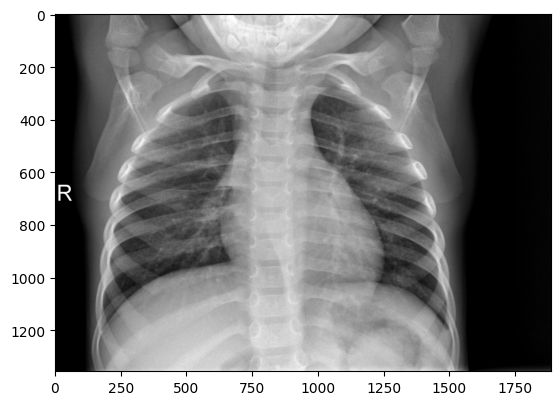

In [11]:
# converting the images into grayscale
for i in CATEGORIES:
    path = os.path.join(DataDir,i)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array,cmap='gray')
        plt.show()
        break
    break

In [12]:
# initializing the size of img so all img has same dimention
img_size = 100

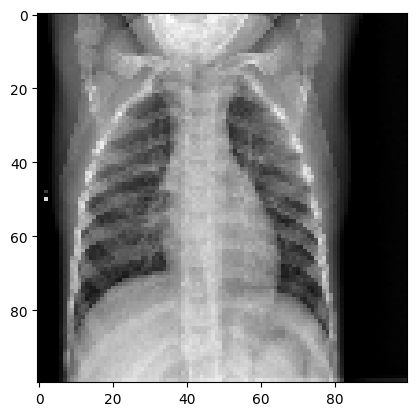

In [13]:
# image after resize and gray scale
new_array = cv2.resize(img_array,(img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [14]:
training_data=[]

In [15]:
# defining the function for training data according to the categories convertion the images into gray scale with resolution
# converting it into numpy arrays
def create_training_data():
  for i in CATEGORIES:
    path = os.path.join(DataDir,i)
    class_num = CATEGORIES.index(i)

    for img in os.listdir(path):
      try:
        img_array = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        new_array = cv2.resize(img_array,(img_size,img_size))
        training_data.append([new_array,class_num])
      except Exception as e:
        pass

In [16]:
create_training_data()

In [17]:
print(len(training_data))

5226


In [18]:
import random
random.shuffle(training_data)
for sample in training_data[:10]:
  print(sample)

[array([[134, 106,  94, ...,  13,  15,  28],
       [129, 120, 142, ...,  16,  12,  47],
       [125, 126,  77, ...,  40,  14,  48],
       ...,
       [ 31,  33,  29, ...,  37,  36,  35],
       [ 33,  32,  29, ...,  36,  37,  37],
       [ 33,  33,  29, ...,  37,  37,  37]], dtype=uint8), 1]
[array([[ 80,  60,  56, ..., 123, 165,  79],
       [ 80,  68,  63, ..., 129, 162,  79],
       [ 90,  79,  70, ..., 140, 102,  78],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   1,   0,   0]], dtype=uint8), 0]
[array([[33, 54, 79, ..., 46, 22,  0],
       [34, 52, 75, ..., 42, 19,  0],
       [32, 48, 74, ..., 44, 19,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0]
[array([[66, 65, 64, ..., 55, 52, 49],
       [80, 69, 66, ..., 57, 53, 50],
       [76, 83, 77, ..., 55, 54, 47],
       ...,
       [32, 51, 75, ...,

In [19]:
X=[]
y=[]

In [20]:
# splitting the feature and labels
for features,labels in training_data:
  X.append(features)
  y.append(labels)

In [21]:
print(X[0].reshape(-1,img_size,img_size,1))

[[[[134]
   [106]
   [ 94]
   ...
   [ 13]
   [ 15]
   [ 28]]

  [[129]
   [120]
   [142]
   ...
   [ 16]
   [ 12]
   [ 47]]

  [[125]
   [126]
   [ 77]
   ...
   [ 40]
   [ 14]
   [ 48]]

  ...

  [[ 31]
   [ 33]
   [ 29]
   ...
   [ 37]
   [ 36]
   [ 35]]

  [[ 33]
   [ 32]
   [ 29]
   ...
   [ 36]
   [ 37]
   [ 37]]

  [[ 33]
   [ 33]
   [ 29]
   ...
   [ 37]
   [ 37]
   [ 37]]]]


In [22]:
y =np.array(y)

In [23]:
# reshapping the features for making it compatible with tensorflow
X  = np.array(X).reshape(-1,img_size,img_size,1)

In [24]:
# as we do for training data similarly doing with validation data
validation_data=[]
DataDir_val =r"chest_xray/val/"

In [25]:
def create_validating_data():
  for i in CATEGORIES:
    path = os.path.join(DataDir_val,i)
    class_num = CATEGORIES.index(i)

    for img in os.listdir(path):
      try:
        img_array = cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        new_array = cv2.resize(img_array,(img_size,img_size))
        validation_data.append([new_array,class_num])
      except Exception as e:
        pass

In [26]:
#DataDir_val =r"chest_xray/val/"
create_validating_data()

print(len(validation_data))

16


In [27]:
import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
  print(sample)

[array([[  0,  85, 102, ...,  95,  73,  51],
       [ 50,  77,  90, ...,  83,  60,  39],
       [ 44,  62,  95, ...,  76,  55,  34],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8), 0]
[array([[ 2, 17, 31, ..., 95, 86, 68],
       [ 6, 14, 25, ..., 94, 68, 62],
       [ 2, 10, 23, ..., 88, 73, 60],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0]
[array([[10, 32, 26, ..., 71, 64, 56],
       [11, 38, 35, ..., 79, 68, 61],
       [13, 37, 38, ..., 81, 76, 66],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0]
[array([[0, 1, 3, ..., 0, 0, 0],
       [0, 0, 2, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 

In [28]:
X_val=[]
y_val=[]

In [29]:
for features,labels in validation_data:
  X_val.append(features)
  y_val.append(labels)

In [30]:
y_val =np.array(y_val)
X_val  = np.array(X_val).reshape(-1,img_size,img_size,1)

In [31]:
# importing the library for train the mode and add the neural network layer

In [32]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten
import pickle

In [33]:
from keras.layers import Conv2D,MaxPooling2D

In [34]:
# scaling because pixels ranges from 0 to 255
X = X/255.0
x_val =X_val/255.0

In [35]:
X.shape

(5226, 100, 100, 1)

In [36]:
x_val.shape

(16, 100, 100, 1)

In [37]:
# intializing model
model= Sequential()

model.add(Conv2D(64,(3,3),input_shape=X.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(128,(3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(256,(3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(64))

model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation("sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])

In [40]:
# fitting model with 10 epochs and using validation data we have created
model.fit(X,y,batch_size=4,epochs=10,validation_data=(x_val,y_val))

Epoch 1/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 270s 205ms/step - accuracy: 0.8728 - loss: 0.3132 - val_accuracy: 0.8125 - val_loss: 0.3036
Epoch 2/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 264s 202ms/step - accuracy: 0.9386 - loss: 0.1637 - val_accuracy: 0.6875 - val_loss: 0.7470
Epoch 3/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 265s 202ms/step - accuracy: 0.9483 - loss: 0.1379 - val_accuracy: 0.8125 - val_loss: 0.3142
Epoch 4/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 325s 205ms/step - accuracy: 0.9556 - loss: 0.1220 - val_accuracy: 0.8125 - val_loss: 0.3629
Epoch 5/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 266s 204ms/step - accuracy: 0.9592 - loss: 0.1121 - val_accuracy: 0.8125 - val_loss: 0.2855
Epoch 6/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 319s 202ms/step - accuracy: 0.9638 - loss: 0.0938 - val_accuracy: 0.8750 - val_loss: 0.2986
Epoch 7/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 322s 202ms/step - accuracy: 0.9656 - loss: 0.0896 - val_accuracy: 1.0000 - val_loss: 0.1152
Epoch 8/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 265s 202ms/step - ac

In [41]:
# saving model
model.save(r"/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/model_10.h5")

In [42]:
# testing the model '

import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from keras.models import load_model

In [43]:
CATEGORIES =["NORMAL","PNEUMONIA"]


In [44]:
# function for preparing the image for prediction the class
def prepare(image):
  img_size =100
  # img_array = cv2.imread(image,cv2.IMREAD_GRAYSCALE )
  img = tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
  new_array = tf.keras.preprocessing.image.img_to_array(img)
  new_array = np.array(new_array).reshape(-1,img_size,img_size,1)

  return new_array.reshape(-1, img_size, img_size, 1)

In [45]:
import os
model = tf.keras.models.load_model("/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/model_10.h5")

In [46]:
image = r'/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/test/NORMAL/IM-0006-0001.jpeg'

In [47]:
prediction = model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[round(prediction[0][0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
[[0.81955755]]
1
PNEUMONIA


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(1, 100, 100, 1))',)
  warnings.warn(msg)


In [48]:
image2 = r'/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/test/PNEUMONIA/person100_bacteria_478.jpeg'

In [49]:
prediction = model.predict([prepare(image2)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[round(prediction[0][0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[0.9999966]]
1
PNEUMONIA


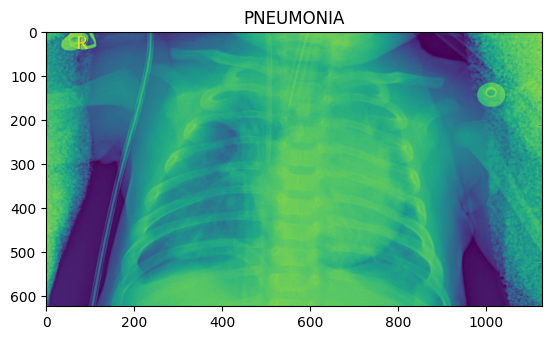

In [50]:
img = mpimg.imread(image2)
implot=plt.imshow(img)
plt.title(CATEGORIES[round(prediction[0][0])])
plt.show()

In [51]:
image3 = r'/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/test/NORMAL/IM-0009-0001.jpeg'

In [52]:
prediction = model.predict([prepare(image3)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[round(prediction[0][0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[0.9663096]]
1
PNEUMONIA


In [53]:
# importing necessary libraries
import os
import cv2
import numpy as np
import tensorflow as tf
from keras.models import load_model

# set the path for test data
test_dir = "/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/test"

# define categories
CATEGORIES = ["NORMAL", "PNEUMONIA"]

# set image size
img_size = 100

# load the saved model
model = load_model('/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/model_10.h5')

# intialize lists for storing test data
X_test = []
y_test = []

# loop through the test data directory and extract the images and their labels
for category in CATEGORIES:
  path = os.path.join(test_dir, category)
  class_num = CATEGORIES.index(category)
  for img in os.listdir(path):
    try:
      img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
      new_array = cv2.resize(img_array, (img_size, img_size))
      X_test.append(new_array)
      y_test.append(class_num)
    except Exception as e:
      pass



# convert test data to numpy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# normalize test data
X_test = X_test / 255.0

# calculate the test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose = 2)
print('Test accuracy:', test_acc)

20/20 - 12s - 589ms/step - accuracy: 0.7196 - loss: 1.4817
Test accuracy: 0.7195512652397156


# Pre - Trained Models

In [54]:
# import necessary libraries
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# define image size
img_size = 100

# load the pre-trained model(VGG16)
base_model = VGG16(input_shape=(img_size,img_size,3), include_top = False, weights='imagenet')

# freeze thee layers of the pre -trained model
for layer in base_model.layers:
  layer.trainable = False

# add ncustom layer for classification
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# create the final model
model = Model(inputs=base_model.input, outputs=predictions)


# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# define the image generators for training and validation data
train_datagen = ImageDataGenerator(rescale=1./255, shear_range= 0.2 , zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# specify the training and validation data directories
train_dir = "/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/train"
val_dir = "/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/val"

#create the image generators for training and validation data
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary')

# train the model
model.fit(train_generator, epochs=10, validation_data=val_generator)

# evaluate the model
test_dir = "/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/test"
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary', shuffle=False)
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Found 5226 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1726s 11s/step - accuracy: 0.9137 - loss: 0.2112 - val_accuracy: 0.8125 - val_loss: 0.3516
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 618s 4s/step - accuracy: 0.9416 - loss: 0.1543 - val_accuracy: 0.7500 - val_loss: 0.6322
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 618s 4s/step - accuracy: 0.9445 - loss: 0.1469 - val_accuracy: 0.8125 - val_loss: 0.3376
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 619s 4s/step - accuracy: 0.9531 - loss: 0.1278 - val_accuracy: 0.8125 - val_loss: 0.2850
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 623s 4s/step - accuracy: 0.9493 - loss: 0.1339 - val_accuracy: 0.6250 - val_loss: 0.7641
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 612s 4s/step - accuracy: 0.9497 - loss: 0.1317 - val_accuracy: 0.8750 - val_loss: 0.1817
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 621s 4s/step - accuracy: 0.9524 - loss: 0.1257 - va

In [55]:
# saving the model
model.save('/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/model_vgg16.h5')

In [56]:
model = tf.keras.models.load_model('/content/drive/MyDrive/Deep learning/chest_xray-20250726T110654Z-1-001/chest_xray/model_vgg16.h5')

In [57]:
model.summary()

Model: "functional_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,935,811 (60.79 MB)

 Trainable params: 1,221,121 (4.66 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2 (12.00 B)